<a href="https://colab.research.google.com/github/cknimi/fraud-detection/blob/main/Fraud_detection_in_MMTusing_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
path="/content/drive/MyDrive/Dataset/Fraud Prediction.csv"
df=pd.read_csv(path)
df.head()# Reading the dataset

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Exploratory Data Analysis

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,f1_score,precision_score,recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from imblearn.over_sampling import SMOTE

Understanding the structure of the data

In [ ]:
df.shape

(6362620, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


Understand the Distribution of the Target Variable

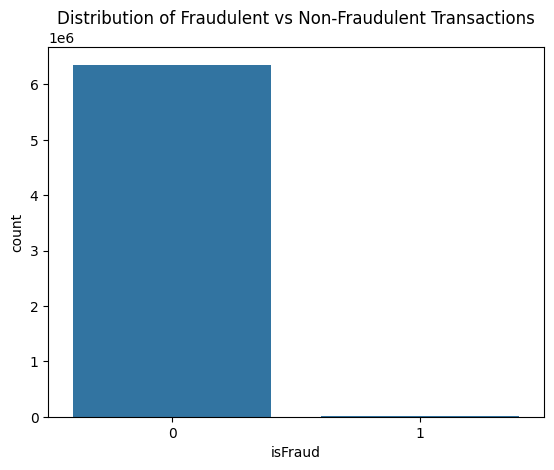

In [ ]:
# Check the distribution of the 'isFraud' variable
df['isFraud'].value_counts()
# Visualize the distribution of the target variable
sns.countplot(x='isFraud', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.show()

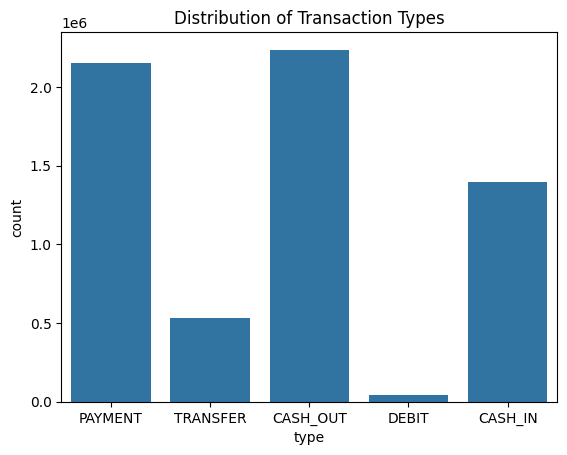

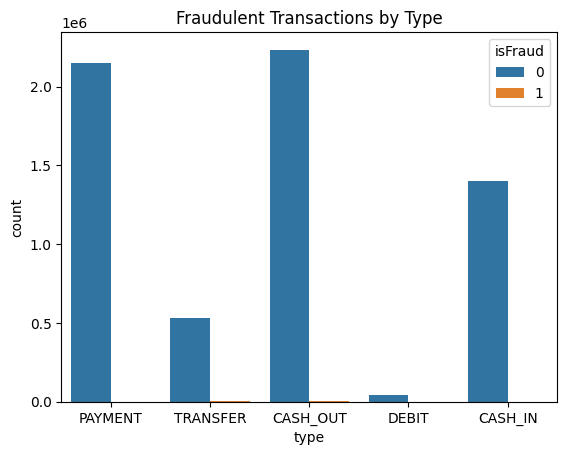

In [ ]:
# Check the distribution of transaction types
df['type'].value_counts()
# Visualize the distribution of transaction types
sns.countplot(x='type', data=df)
plt.title('Distribution of Transaction Types')
plt.show()
# Analyze the relationship between transaction type and fraud
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Fraudulent Transactions by Type')
plt.show()

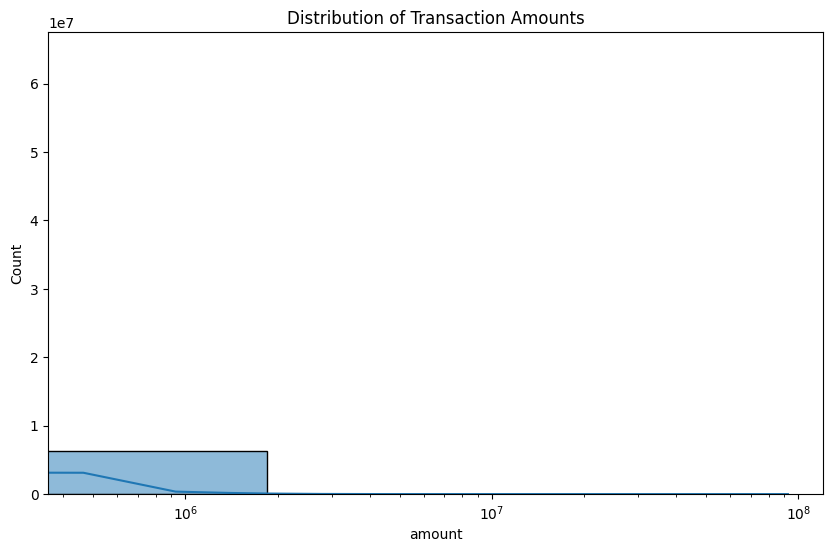

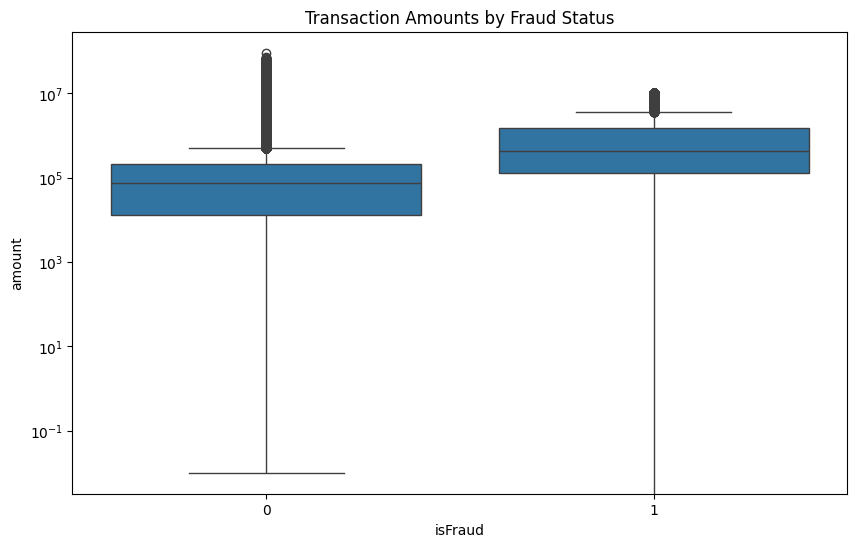

In [ ]:
# Visualize the distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xscale('log')
plt.show()
# Compare transaction amounts between fraudulent and non-fraudulent transactions
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title('Transaction Amounts by Fraud Status')
plt.show()

#  Data Preproceesing

In [ ]:
df.groupby('isFlaggedFraud').count()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
isFlaggedFraud,,,,,,,,,,
0,6362604,6362604,6362604,6362604,6362604,6362604,6362604,6362604,6362604,6362604
1,16,16,16,16,16,16,16,16,16,16


The preceding line groups the DataFrame by the 'isFlaggedFraud' column and then counts the number of non-null values in each column for each group. This is frequently used to compare the number of transactions marked as possibly fraudulent to those that have not been flagged.It has been noted that only 16 records are in this group which means this column is not relevant.so it can be dropped.

In [ ]:
df.groupby('type').count()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
type,,,,,,,,,,
CASH_IN,1399284,1399284,1399284,1399284,1399284,1399284,1399284,1399284,1399284,1399284
CASH_OUT,2237500,2237500,2237500,2237500,2237500,2237500,2237500,2237500,2237500,2237500
DEBIT,41432,41432,41432,41432,41432,41432,41432,41432,41432,41432
PAYMENT,2151495,2151495,2151495,2151495,2151495,2151495,2151495,2151495,2151495,2151495
TRANSFER,532909,532909,532909,532909,532909,532909,532909,532909,532909,532909


The above line groups the DataFrame by the 'type' column and counts the number of non-null values in each column for each unique transaction type.

In [ ]:
df.pivot_table(values='amount',index='type',columns='isFraud',aggfunc='count')

isFraud,0,1
type,,
CASH_IN,1399284.0,NaN
CASH_OUT,2233384.0,4116.0
DEBIT,41432.0,NaN
PAYMENT,2151495.0,NaN
TRANSFER,528812.0,4097.0


Created a pivot table to count the number of transactions for each transaction type (type), separated by whether they are fraudulent (isFraud = 1) or not. This is useful for summarizing and comparing the distribution of fraudulent versus non-fraudulent transactions across different types

from the above results,it is clear that only 'cash_out' and 'transfer' has frauds

In [ ]:
dffiltter=df[df.type.isin(['CASH_OUT','TRANSFER'])]#The filtered DataFrame is stored in a new DataFrame called dffiltter, which contains only the rows where type is 'CASH_OUT' or 'TRANSFER'.
dffiltter.pivot_table(values='amount',index='type',columns='isFraud',aggfunc='count')#creates a pivot table from the filtered data dffiltter.The pivot table summarizes the count of transactions (amount entries) for each combination of type (CASH_OUT and TRANSFER) and isFraud (0 for non-fraudulent, 1 for fraudulent).

isFraud,0,1
type,,
CASH_OUT,2233384,4116
TRANSFER,528812,4097


Now we need to encode the type variable using label encoder

In [ ]:
e=LabelEncoder()
dffiltter['typeEncoded']=e.fit_transform(dffiltter['type'])
dffiltter.pivot_table(values='amount',index='typeEncoded',columns='isFraud',aggfunc='count')

<ipython-input-14-1112848a78b4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dffiltter['typeEncoded']=e.fit_transform(dffiltter['type'])


isFraud,0,1
typeEncoded,,
0,2233384,4116
1,528812,4097


Hence CASH_OUT and TRANSFER has been encoded as 0 and 1 respectively




In [ ]:
dffiltter.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,typeEncoded
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,0
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,1
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,1


In [ ]:
df3=dffiltter.drop(['step','type','nameOrig','nameDest','isFlaggedFraud'],axis=1)

In [ ]:
df3.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,typeEncoded
2,181.00,181.0,0.0,0.0,0.00,1,1
3,181.00,181.0,0.0,21182.0,0.00,1,0
15,229133.94,15325.0,0.0,5083.0,51513.44,0,0
19,215310.30,705.0,0.0,22425.0,0.00,0,1
24,311685.89,10835.0,0.0,6267.0,2719172.89,0,1


Data splitting

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df3.drop(['isFraud'],axis=1),df3.isFraud,test_size=.3,random_state=42)

In [ ]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

In [ ]:
# Fit and transform the training data
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
# Print class distribution
print("Original class distribution:")
print(y_train.value_counts())
print("Resampled class distribution:")
print(pd.Series(y_resampled).value_counts())

Original class distribution:
isFraud
0    1933569
1       5717
Name: count, dtype: int64
Resampled class distribution:
isFraud
0    1933569
1    1933569
Name: count, dtype: int64


**Model Building using LogisticRegression**

In [ ]:
log_reg=LogisticRegression()

In [ ]:
log_reg.fit(X_resampled, y_resampled)

LogisticRegression()

In [ ]:
y_pred = log_reg.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [ ]:
# Print evaluation metrics
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')

Accuracy: 0.8999462173468908
Confusion Matrix:
[[745533  83094]
 [    63   2433]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    828627
           1       0.03      0.97      0.06      2496

    accuracy                           0.90    831123
   macro avg       0.51      0.94      0.50    831123
weighted avg       1.00      0.90      0.94    831123



Confusion Matrix

<Axes: >

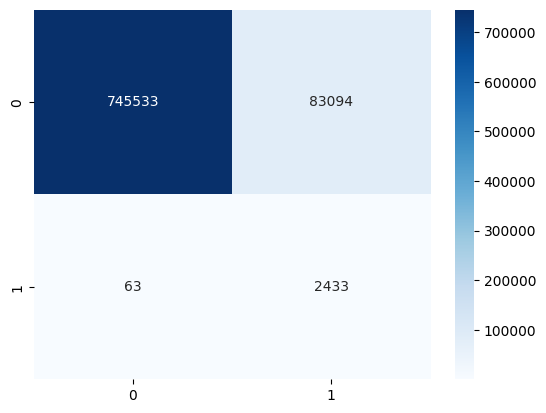

In [ ]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')

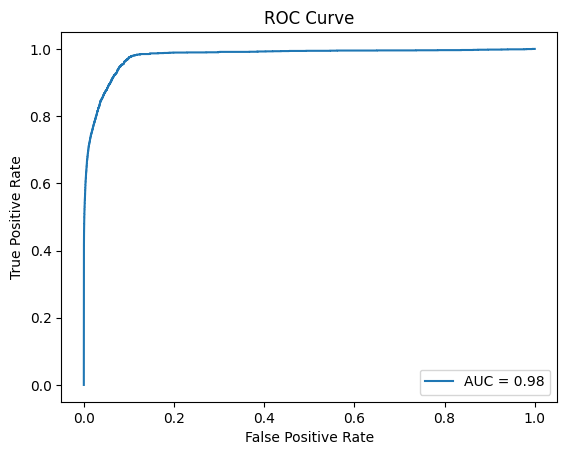

In [ ]:
# ROC Curve
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_prob):.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Model Training with Regularization

In [ ]:
# L1 Regularization (Lasso)
logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0)
logreg_l1.fit(X_train, y_train)
y_pred_l1 = logreg_l1.predict(X_test)
print("L1 Regularization Accuracy:", accuracy_score(y_test, y_pred_l1))

L1 Regularization Accuracy: 0.9981964161742606


In [ ]:
# L2 Regularization (Ridge)
logreg_l2 = LogisticRegression(penalty='l2', solver='liblinear', C=1.0)
logreg_l2.fit(X_train, y_train)
y_pred_l2 = logreg_l2.predict(X_test)
print("L2 Regularization Accuracy:", accuracy_score(y_test, y_pred_l2))

L2 Regularization Accuracy: 0.9972807875609266


In [ ]:
predicted=logreg_l2.predict(X_test)

In [ ]:
logreg_l2.score(X_test,y_test)

0.9972807875609266

I has been noitced that both the Lasso and Ridge model performs exceptionally well.
let us choose Ridge model for the performace evaluation

# Evaluation Metrics

1.Confusion Matrix

In [ ]:
confmat=confusion_matrix(y_test,predicted)

In [ ]:
confmat

array([[827069,   1558],
       [   702,   1794]])

<Axes: >

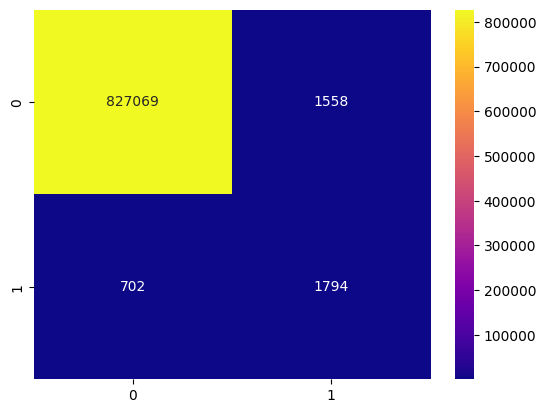

In [ ]:
sns.heatmap(confmat,annot=True,fmt='d',cmap='plasma')

2.ROC-AUC SCORE/ROC-AUC CURVE

In [ ]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, predicted)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8584348906383692


The model's ROC-AUC score is 0.8, indicating acceptable performance. It can fairly discriminate between positive and negative classes.

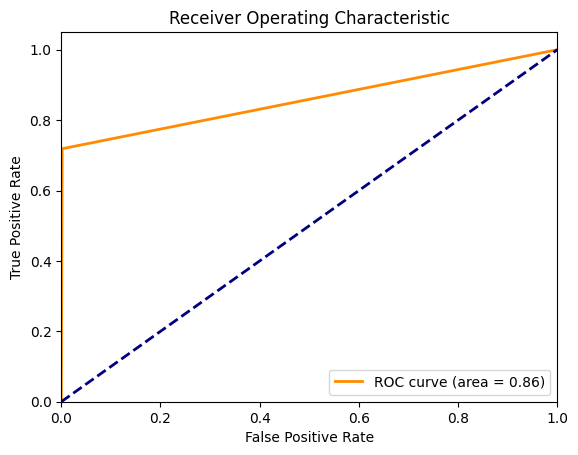

AUC: 0.8584348906383692


In [ ]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, predicted)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Print AUC value
print("AUC:", roc_auc)

The graph shows that the ROC AUC is high (near to 1),so this graph too indicating that the model has a great capacity to distinguish between positive and negative classes.

3.F1 Score

In [ ]:
# F1 Score
f1 = f1_score(y_test,predicted)
print("F1 Score:", f1)

F1 Score: 0.6135430916552668


f1 score lies between 0.6-0.7 which indicates a decent performance of the model

4.Precision and Recall

In [ ]:
# Calculate Precision
precision = precision_score(y_test,predicted)
print("Precision:", precision)

# Calculate Recall
recall = recall_score(y_test,predicted)
print("Recall:", recall)

Precision: 0.5352028639618138
Recall: 0.71875


A model with a precision of 0.5 means that only half of the occurrences predicted as positive by the model are actually positive. In other words, half of the model's positive predictions are right, while the other half are incorrect (false positive).
A recall greater than 0.7 indicates that the model successfully recognizes more than 70% of all true positive events. In other words, while the model accurately recognizes the majority of positive situations, it may miss up to 30% of true positives (known as false negatives).

Let us get an in-depth examination of all the various indicators used to measure the performance of the model utilizing the classification report.

In [ ]:
print(classification_report(y_test,predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828627
           1       0.54      0.72      0.61      2496

    accuracy                           1.00    831123
   macro avg       0.77      0.86      0.81    831123
weighted avg       1.00      1.00      1.00    831123



**Model Building**
**using Decision Tree**

In [ ]:
DTModel1=DecisionTreeClassifier()

In [ ]:
DTModel1.fit(X_resampled, y_resampled)

DecisionTreeClassifier()

In [ ]:
DTpredicted1=DTModel1.predict(X_test)

**Evaluation Metrics**


1.Confusion Matrix

In [ ]:
cm=confusion_matrix(y_test,DTpredicted1)
print(cm)

[[827600   1027]
 [    52   2444]]


<Axes: >

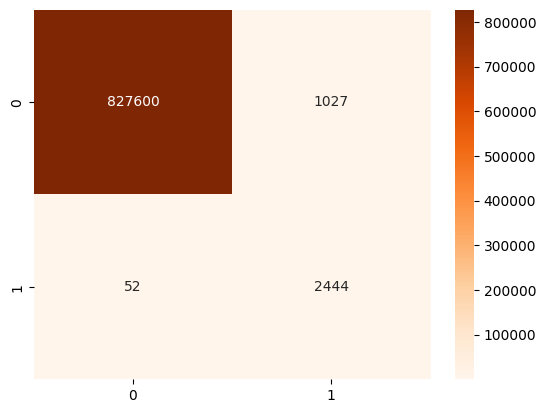

In [ ]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')

2.ROC-AUC SCORE/ROC-AUC CURVE

In [ ]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, DTpredicted1)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9889636335166485


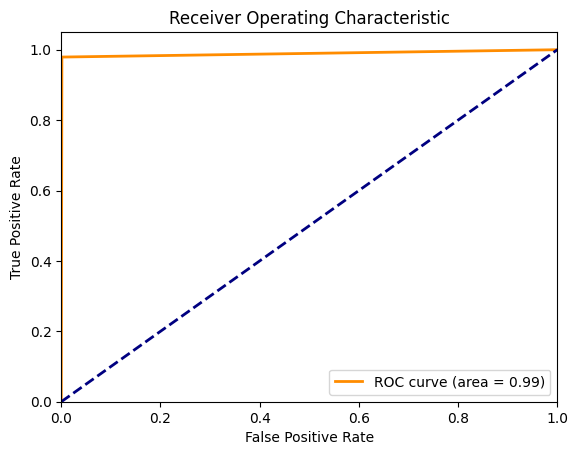

AUC: 0.9889636335166485


In [ ]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, DTpredicted1)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Print AUC value
print("AUC:", roc_auc)

 This score indicates that the model has excellent performance with strong discriminatory power.there's a 99% chance that the model will correctly rank a randomly chosen positive instance higher than a randomly chosen negative instance.

3-F1 Score

In [ ]:
# F1 Score
f1 = f1_score(y_test,DTpredicted1)
print("F1 Score:", f1)

F1 Score: 0.8191721132897605


An F1 score of 0.8 indicates excellent performance, implying that the model achieves a solid balance between precision and recall. This indicates that the model correctly identifies positive cases while missing few genuine positives.

4.Precision and Recall

In [ ]:
# Calculate Precision
precision = precision_score(y_test,DTpredicted1)
print("Precision:", precision)

# Calculate Recall
recall = recall_score(y_test,DTpredicted1)
print("Recall:", recall)

Precision: 0.704119850187266
Recall: 0.9791666666666666


 Recall of 0.98 means that the model correctly identifies 98% of the actual positive instances.The score also indicates that the model is very good at capturing the positive class and minimizing false negatives.
 The precision of 0.7 indicates that while the model is good at identifying most of the positives, it also makes some incorrect positive predictions. This could mean that the model sometimes labels negative instances as positive, leading to false positives.

In [ ]:
accuracy = accuracy_score(y_test, DTpredicted1)
print(f'Accuracy: {accuracy}')


Accuracy: 0.9987017565390441


Let us get an in-depth examination of all the various indicators used to measure the performance of the model utilizing the classification report.

In [ ]:
print(classification_report(y_test,DTpredicted1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828627
           1       0.70      0.98      0.82      2496

    accuracy                           1.00    831123
   macro avg       0.85      0.99      0.91    831123
weighted avg       1.00      1.00      1.00    831123



parameter Tuning

In [ ]:
# Define the hyperparameters grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],  # Criterion for measuring the quality of a split
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 20],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 5, 10]  # Minimum number of samples required to be at a leaf node
}

In [ ]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=DTModel1, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
# Fit the model to the training data
grid_search.fit(X_resampled, y_resampled)
# Output the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 3 folds for each of 192 candidates, totalling 576 fits
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_
# Make predictions on the test data
y_pred = best_model.predict(X_test)
# Evaluate the model's performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[827707    920]
 [    39   2457]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828627
           1       0.73      0.98      0.84      2496

    accuracy                           1.00    831123
   macro avg       0.86      0.99      0.92    831123
weighted avg       1.00      1.00      1.00    831123



In [ ]:
# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
# Print the accuracy
print(f"Accuracy after tuning: {accuracy:.4f}")

Accuracy after tuning: 0.9988


**Model Building using K Nearest Neighbor(KNN)**

Standardization ensures that all variables contribute equally to the similarity measures.Thus, while creating KNN models, data normalization must be performed after the train-test split.

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Initialize the kNN classifier
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
# Train the model
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
KNNpredicted=knn.predict(X_test_scaled)

**Evaluation Metrics**

1.Confusion Matrix

In [ ]:
cm1=confusion_matrix(y_test,KNNpredicted)
cm1

array([[828456,    171],
       [   564,   1932]])

<Axes: >

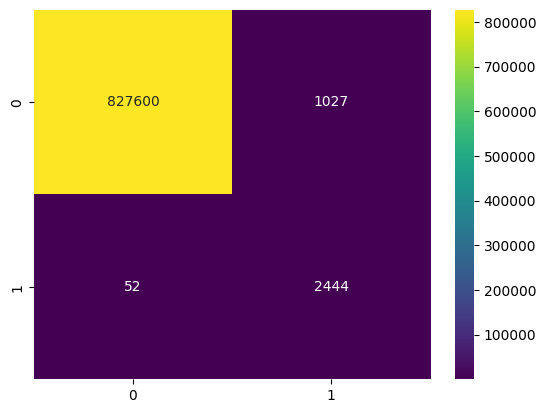

In [ ]:
sns.heatmap(cm,annot=True,fmt='d',cmap='viridis')

2.ROC-AUC SCORE/ROC-AUC CURVE

In [ ]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, KNNpredicted)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8869160480344177


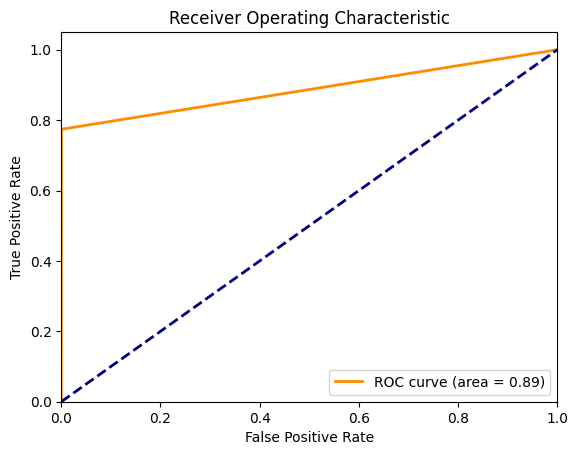

AUC: 0.8869160480344177


In [ ]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, KNNpredicted)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Print AUC value
print("AUC:", roc_auc)

An AUC of 0.88 indicates that the model can distinguish between positive and negative classes. Specifically, the model has an 88% chance of ranking a randomly chosen positive instance higher than a randomly chosen negative one.

3-F1 Score

In [ ]:
# F1 Score
f1 = f1_score(y_test,KNNpredicted)
print("F1 Score:", f1)

F1 Score: 0.8401826484018265


4.Precision and Recall

In [ ]:
# Calculate Precision
precision = precision_score(y_test,KNNpredicted)
print("Precision:", precision)

# Calculate Recall
recall = recall_score(y_test,KNNpredicted)
print("Recall:", recall)

Precision: 0.9186875891583453
Recall: 0.7740384615384616


The above scores indicates that the model is careful and only predicts positives when confident, resulting in high precision.However, because of this caution, the model might ignore some true positive cases, as shown by the reduced recall.

Let us take a detailed look at all of the numerous variables utilized to assess the model's performance using the classification report.

In [ ]:
accuracy = accuracy_score(y_test, KNNpredicted)
print(f'Accuracy: {accuracy}')


Accuracy: 0.9991156543616287


In [ ]:
print(classification_report(y_test,KNNpredicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828627
           1       0.92      0.77      0.84      2496

    accuracy                           1.00    831123
   macro avg       0.96      0.89      0.92    831123
weighted avg       1.00      1.00      1.00    831123



Hyperparameter Tuning using GridSerachCV

In [ ]:
# Initialize the KNeighborsClassifier
knn = KNeighborsClassifier()
# Define the hyperparameters grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Number of neighbors to use
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metric
}

In [ ]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=3,scoring='accuracy', n_jobs=-1, verbose=2)
# Fit the model to the training data
grid_search.fit(X_train, y_train)
# Output the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}


In [ ]:
# Use the best model found by GridSearchCV
best_knn_model = grid_search.best_estimator_
# Make predictions on the test data
y_pred = best_knn_model.predict(X_test)
# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy after tuning: {accuracy:.4f}")
# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy after tuning: 0.9990

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828627
           1       0.90      0.74      0.81      2496

    accuracy                           1.00    831123
   macro avg       0.95      0.87      0.91    831123
weighted avg       1.00      1.00      1.00    831123



In [ ]:
#confusion matrix
cm2=confusion_matrix(y_test,y_pred)
cm2

array([[828428,    199],
       [   651,   1845]])

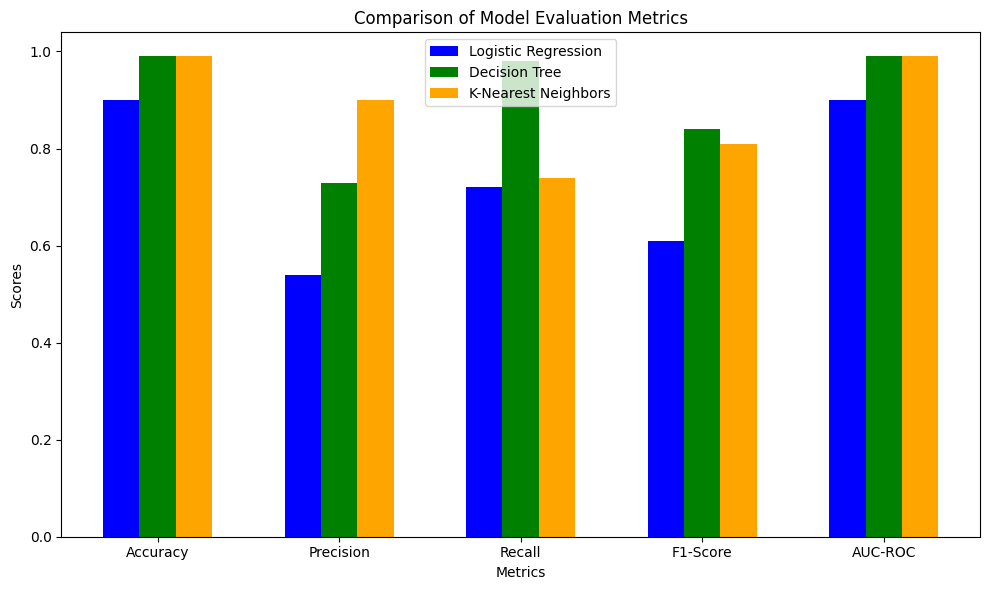

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics values for each model (sample values)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
lr_scores = [0.90, 0.54, 0.72, 0.61, 0.90]  # Logistic Regression scores
dt_scores = [0.99, 0.73, 0.98, 0.84, 0.99]  # Decision Tree scores
knn_scores = [0.99, 0.90, 0.74, 0.81, 0.99] # KNN scores
# Define the x-axis positions for each group of bars
bar_width = 0.2
index = np.arange(len(metrics))
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
# Plotting each model's bars
ax.bar(index, lr_scores, bar_width, label='Logistic Regression', color='blue')
ax.bar(index + bar_width, dt_scores, bar_width, label='Decision Tree', color='green')
ax.bar(index + 2 * bar_width, knn_scores, bar_width, label='K-Nearest Neighbors', color='orange')
# Add labels, title, and legend
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Model Evaluation Metrics')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(metrics)
ax.legend()
# Show plot
plt.tight_layout()
plt.show()

From the above results,it is clear that all the three models performed very well.Logistic regression showed an accuracy of 90% wheras Decision Tree showed 99.8% and KNN showed 99.9% of accuracy .However accuracy can be considered a good metric for imbalanced dataset as it can be biased to the minority class.So other metrics such as precision,recall,f1 score and AUC-ROC score can be considered to evaluate the best model.

